<p style="text-align:center">
    <a href="https://skills.network/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMDS0321ENSkillsNetwork26802033-2022-01-01" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo">
    </a>
</p>


# **Space X  Falcon 9 First Stage Landing Prediction**


## Hands on Lab: Complete the Machine Learning Prediction lab


Estimated time needed: **60** minutes


Space X advertises Falcon 9 rocket launches on its website with a cost of 62 million dollars; other providers cost upward of 165 million dollars each, much of the savings is because Space X can reuse the first stage. Therefore if we can determine if the first stage will land, we can determine the cost of a launch. This information can be used if an alternate company wants to bid against space X for a rocket launch.   In this lab, you will create a machine learning pipeline  to predict if the first stage will land given the data from the preceding labs.


![](https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DS0701EN-SkillsNetwork/api/Images/landing_1.gif)


Several examples of an unsuccessful landing are shown here:


![](https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DS0701EN-SkillsNetwork/api/Images/crash.gif)


Most unsuccessful landings are planed. Space X; performs a controlled landing in the oceans.


## Objectives


Perform exploratory  Data Analysis and determine Training Labels

*   create a column for the class
*   Standardize the data
*   Split into training data and test data

\-Find best Hyperparameter for SVM, Classification Trees and Logistic Regression

*   Find the method performs best using test data


## Import Libraries and Define Auxiliary Functions


In [1]:
import piplite
await piplite.install(['numpy'])
await piplite.install(['pandas'])
await piplite.install(['seaborn'])

We will import the following libraries for the lab


In [2]:
# Pandas is a software library written for the Python programming language for data manipulation and analysis.
import pandas as pd
# NumPy is a library for the Python programming language, adding support for large, multi-dimensional arrays and matrices, along with a large collection of high-level mathematical functions to operate on these arrays
import numpy as np
# Matplotlib is a plotting library for python and pyplot gives us a MatLab like plotting framework. We will use this in our plotter function to plot data.
import matplotlib.pyplot as plt
#Seaborn is a Python data visualization library based on matplotlib. It provides a high-level interface for drawing attractive and informative statistical graphics
import seaborn as sns
# Preprocessing allows us to standarsize our data
from sklearn import preprocessing
# Allows us to split our data into training and testing data
from sklearn.model_selection import train_test_split
# Allows us to test parameters of classification algorithms and find the best one
from sklearn.model_selection import GridSearchCV
# Logistic Regression classification algorithm
from sklearn.linear_model import LogisticRegression
# Support Vector Machine classification algorithm
from sklearn.svm import SVC
# Decision Tree classification algorithm
from sklearn.tree import DecisionTreeClassifier
# K Nearest Neighbors classification algorithm
from sklearn.neighbors import KNeighborsClassifier

<ipython-input-2-b7d446354769>:2: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


This function is to plot the confusion matrix.


In [3]:
def plot_confusion_matrix(y,y_predict):
    "this function plots the confusion matrix"
    from sklearn.metrics import confusion_matrix

    cm = confusion_matrix(y, y_predict)
    ax= plt.subplot()
    sns.heatmap(cm, annot=True, ax = ax); #annot=True to annotate cells
    ax.set_xlabel('Predicted labels')
    ax.set_ylabel('True labels')
    ax.set_title('Confusion Matrix'); 
    ax.xaxis.set_ticklabels(['did not land', 'land']); ax.yaxis.set_ticklabels(['did not land', 'landed']) 
    plt.show() 

## Load the dataframe


Load the data


In [4]:
from js import fetch
import io

URL1 = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/datasets/dataset_part_2.csv"
resp1 = await fetch(URL1)
text1 = io.BytesIO((await resp1.arrayBuffer()).to_py())
data = pd.read_csv(text1)

In [5]:
data.head()

,FlightNumber,Date,BoosterVersion,PayloadMass,Orbit,LaunchSite,Outcome,Flights,GridFins,Reused,Legs,LandingPad,Block,ReusedCount,Serial,Longitude,Latitude,Class
0,1,2010-06-04,Falcon 9,6104.959412,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0003,-80.577366,28.561857,0
1,2,2012-05-22,Falcon 9,525.000000,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0005,-80.577366,28.561857,0
2,3,2013-03-01,Falcon 9,677.000000,ISS,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0007,-80.577366,28.561857,0
3,4,2013-09-29,Falcon 9,500.000000,PO,VAFB SLC 4E,False Ocean,1,False,False,False,NaN,1.0,0,B1003,-120.610829,34.632093,0
4,5,2013-12-03,Falcon 9,3170.000000,GTO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B1004,-80.577366,28.561857,0


In [6]:
URL2 = 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/datasets/dataset_part_3.csv'
resp2 = await fetch(URL2)
text2 = io.BytesIO((await resp2.arrayBuffer()).to_py())
X = pd.read_csv(text2)

#line for to save feature importance
feature_names = X.columns

In [7]:
X.head(100)

,FlightNumber,PayloadMass,Flights,Block,ReusedCount,Orbit_ES-L1,Orbit_GEO,Orbit_GTO,Orbit_HEO,Orbit_ISS,...,Serial_B1058,Serial_B1059,Serial_B1060,Serial_B1062,GridFins_False,GridFins_True,Reused_False,Reused_True,Legs_False,Legs_True
0,1.0,6104.959412,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
1,2.0,525.000000,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
2,3.0,677.000000,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
3,4.0,500.000000,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
4,5.0,3170.000000,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
85,86.0,15400.000000,2.0,5.0,2.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0
86,87.0,15400.000000,3.0,5.0,2.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0
87,88.0,15400.000000,6.0,5.0,5.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0
88,89.0,15400.000000,3.0,5.0,2.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0


## TASK  1


Create a NumPy array from the column <code>Class</code> in <code>data</code>, by applying the method <code>to_numpy()</code>  then
assign it  to the variable <code>Y</code>,make sure the output is a  Pandas series (only one bracket df\['name of  column']).


In [8]:
Y = data['Class'].to_numpy()
type(Y)
Y

array([0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1,
       1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1,
       1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1], dtype=int64)

## TASK  2


Standardize the data in <code>X</code> then reassign it to the variable  <code>X</code> using the transform provided below.


In [9]:
# students get this 
#!THIS IS DATA LEAKAGE BECAUSE YOU SCALE ALL YOU DATA!
#transform = preprocessing.StandardScaler()
#X = transform.fit_transform(X)
#type(Y)
#X

We split the data into training and testing data using the  function  <code>train_test_split</code>.   The training data is divided into validation data, a second set used for training  data; then the models are trained and hyperparameters are selected using the function <code>GridSearchCV</code>.


## TASK  3


Use the function train_test_split to split the data X and Y into training and test data. Set the parameter test_size to  0.2 and random_state to 2. The training data and test data should be assigned to the following labels.


<code>X_train, X_test, Y_train, Y_test</code>


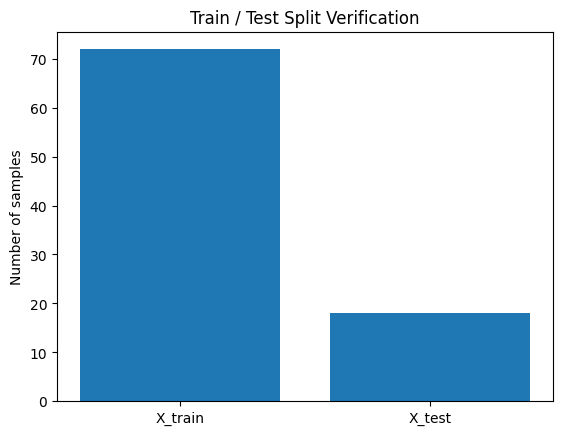

In [10]:
X_train, X_test, Y_train, Y_test = train_test_split(X,Y,test_size = 0.2, random_state = 2)
#validate the training and test data size
train_size = X_train.shape[0]
test_size = X_test.shape[0]

plt.figure()
plt.bar(['X_train', 'X_test'], [train_size, test_size])
plt.ylabel('Number of samples')
plt.title('Train / Test Split Verification')
plt.show()


we can see we only have 18 test samples.


In [11]:
Y_test.shape

(18,)

## TASK  4


Create a logistic regression object  then create a  GridSearchCV object  <code>logreg_cv</code> with cv = 10.  Fit the object to find the best parameters from the dictionary <code>parameters</code>.


In [12]:
# keep a copy before scaling or Pipeline use
X_raw = X.copy()
#WITH PIPELINE and scaling only the training data
from sklearn.pipeline import Pipeline

pipeline_lr = Pipeline([
    ('scaler', preprocessing.StandardScaler()),
    ('lr', LogisticRegression(max_iter=1000))
])

param_grid = {
    'lr__C': [0.01, 0.1, 1],
    'lr__penalty': ['l2'],
    'lr__solver': ['lbfgs']
}
#cross‑validation 
logreg_cv = GridSearchCV(
    pipeline_lr,
    param_grid,
    cv=10
)

logreg_cv.fit(X_train, Y_train)


GridSearchCV(cv=10,
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('lr',
                                        LogisticRegression(max_iter=1000))]),
             param_grid={'lr__C': [0.01, 0.1, 1], 'lr__penalty': ['l2'],
                         'lr__solver': ['lbfgs']})

In [13]:
#parameters ={'C':[0.01,0.1,1],
 #            'penalty':['l2'],
  #           'solver':['lbfgs']}

In [14]:
#parameters ={"C":[0.01,0.1,1],'penalty':['l2'], 'solver':['lbfgs']}# l1 lasso l2 ridge
#lr=LogisticRegression()

#logreg_cv = GridSearchCV(
 #   estimator=lr,
  #  param_grid=parameters,
   # cv=10
#)
#logreg_cv.fit(X_train, Y_train)

We output the <code>GridSearchCV</code> object for logistic regression. We display the best parameters using the data attribute <code>best_params\_</code> and the accuracy on the validation data using the data attribute <code>best_score\_</code>.


In [15]:
print("tuned hpyerparameters :(best parameters) ",logreg_cv.best_params_)
print("accuracy :",logreg_cv.best_score_)


tuned hpyerparameters :(best parameters)  {'lr__C': 0.01, 'lr__penalty': 'l2', 'lr__solver': 'lbfgs'}
accuracy : 0.8464285714285713


## TASK  5


Calculate the accuracy on the test data using the method <code>score</code>:


In [16]:
logreg_cv.score(X_test, Y_test)

0.8333333333333334

Lets look at the confusion matrix:


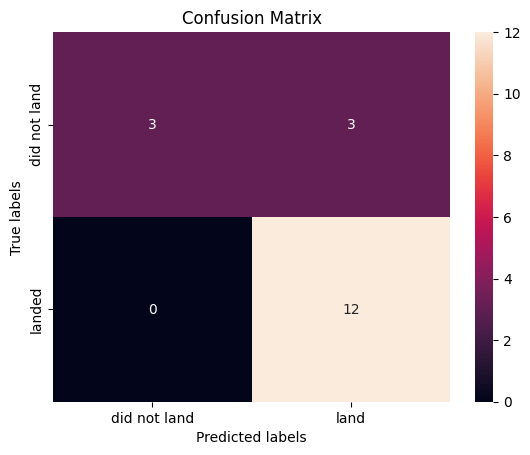

In [17]:
yhat=logreg_cv.predict(X_test)
plot_confusion_matrix(Y_test,yhat)

In [18]:
#extra detailed performance evaluation

from sklearn.metrics import roc_auc_score, classification_report

# Predictions
yhat = logreg_cv.predict(X_test)

# Probabilities + ROC AUC
yhat_proba = logreg_cv.predict_proba(X_test)[:, 1]
print("ROC AUC score:", roc_auc_score(Y_test, yhat_proba))

# Classification report
print(classification_report(Y_test, yhat))


ROC AUC score: 0.888888888888889
              precision    recall  f1-score   support

           0       1.00      0.50      0.67         6
           1       0.80      1.00      0.89        12

    accuracy                           0.83        18
   macro avg       0.90      0.75      0.78        18
weighted avg       0.87      0.83      0.81        18



Examining the confusion matrix, we see that logistic regression can distinguish between the different classes.  We see that the problem is false positives.

Overview:

True Postive - 12 (True label is landed, Predicted label is also landed)

False Postive - 3 (True label is not landed, Predicted label is landed)


<ipython-input-19-c125d70a814f>:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


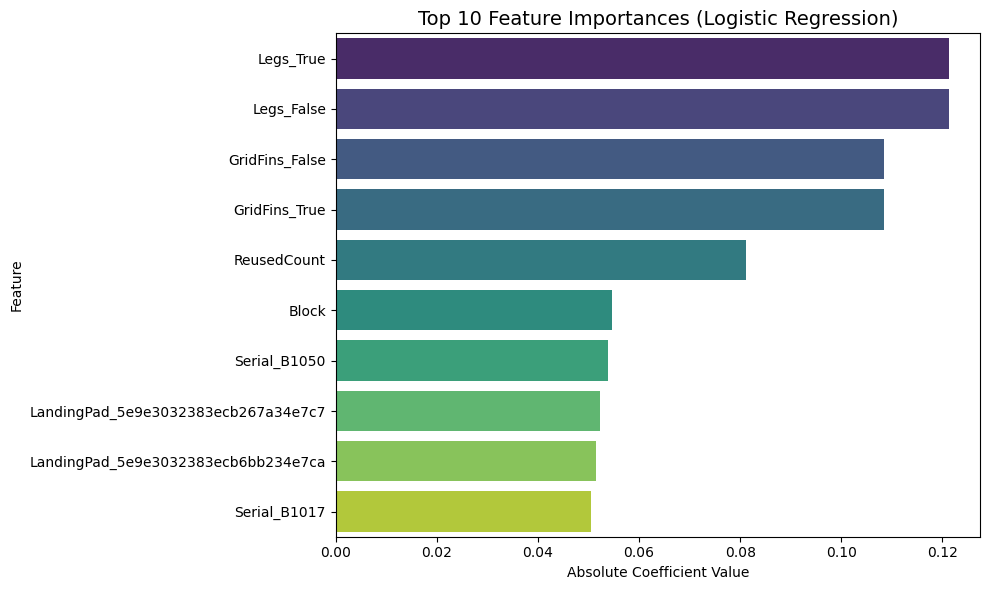

In [19]:

# Extract coefficients importance check
coefficients = logreg_cv.best_estimator_['lr'].coef_[0]

# Build feature-importance table
feature_importance_lr = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients
})

# Rank by absolute influence 
feature_importance_lr['Abs_Coefficient'] = np.abs(feature_importance_lr['Coefficient'])
feature_importance_lr = feature_importance_lr.sort_values(
    by='Abs_Coefficient', ascending=False
)

# Select top 15 
top_features = feature_importance_lr.head(10)

plt.figure(figsize=(10, 6))
sns.barplot(
    x='Abs_Coefficient',
    y='Feature',
    data=top_features,
    palette='viridis'
)

plt.title('Top 10 Feature Importances (Logistic Regression)', fontsize=14)
plt.xlabel('Absolute Coefficient Value')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()


In [20]:
# Extra test, because after scaling the train and test data induviduallysplitting the  
# Access the fitted scaler inside the pipeline
#scaler = logreg_cv.best_estimator_['scaler']
scaler = logreg_cv.best_estimator_['scaler']

#Compare training vs global means
mean_comparison = pd.DataFrame({
    'Training Mean': scaler.mean_,
    'Global Mean': X_raw.mean().values
}, index=feature_names)

mean_comparison



,Training Mean,Global Mean
FlightNumber,45.986111,45.500000
PayloadMass,5987.185940,6104.959412
Flights,1.722222,1.788889
Block,3.597222,3.500000
ReusedCount,1.611111,1.655556
...,...,...
GridFins_True,0.763889,0.777778
Reused_False,0.569444,0.588889
Reused_True,0.430556,0.411111
Legs_False,0.222222,0.211111


## TASK  6


Create a support vector machine object then  create a  <code>GridSearchCV</code> object  <code>svm_cv</code> with cv = 10.  Fit the object to find the best parameters from the dictionary <code>parameters</code>.


In [39]:
pipeline_svm = Pipeline([
    ('scaler', preprocessing.StandardScaler()),
    ('svm', SVC())
])

param_grid_svm = {
    'svm__kernel': ['rbf', 'sigmoid'],
    'svm__C': [0.1, 1, 10],
    'svm__gamma': [0.01, 0.1]
}

svm_cv = GridSearchCV(
    estimator=pipeline_svm,
    param_grid=param_grid_svm,
    cv=10
)

svm_cv.fit(X_train, Y_train)

GridSearchCV(cv=10,
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('svm', SVC())]),
             param_grid={'svm__C': [0.1, 1, 10], 'svm__gamma': [0.01, 0.1],
                         'svm__kernel': ['rbf', 'sigmoid']})

In [40]:
#parameters = {'kernel':('linear', 'rbf','poly','rbf', 'sigmoid'),
 #             'C': np.logspace(-3, 3, 5),
  #            'gamma':np.logspace(-3, 3, 5)}
#svm = SVC()

In [41]:
#svm_cv = GridSearchCV(
 #   estimator=svm,
  #  param_grid=parameters,
   # cv=10
#)
#svm_cv.fit(X_train, Y_train)

In [42]:
print("tuned hpyerparameters :(best parameters) ",svm_cv.best_params_)
print("accuracy :",svm_cv.best_score_)

tuned hpyerparameters :(best parameters)  {'svm__C': 1, 'svm__gamma': 0.01, 'svm__kernel': 'sigmoid'}
accuracy : 0.8482142857142858


## TASK  7


Calculate the accuracy on the test data using the method <code>score</code>:


In [43]:
svm_cv.score(X_test, Y_test)

0.8333333333333334

We can plot the confusion matrix


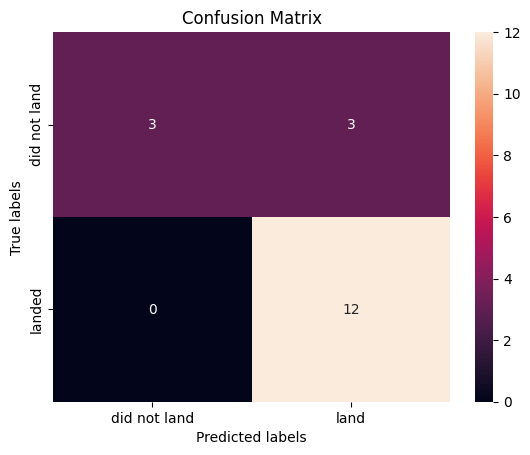

In [44]:
yhat=svm_cv.predict(X_test)
plot_confusion_matrix(Y_test,yhat)

In [45]:
#extra detailed performance evaluation
# Predictions (labels)
yhat = svm_cv.predict(X_test)

# Decision scores (not probabilities)
yhat_scores = svm_cv.decision_function(X_test)

# ROC AUC
print("ROC AUC score:", roc_auc_score(Y_test, yhat_scores))

# Classification report
print(classification_report(Y_test, yhat))

ROC AUC score: 0.8472222222222223
              precision    recall  f1-score   support

           0       1.00      0.50      0.67         6
           1       0.80      1.00      0.89        12

    accuracy                           0.83        18
   macro avg       0.90      0.75      0.78        18
weighted avg       0.87      0.83      0.81        18



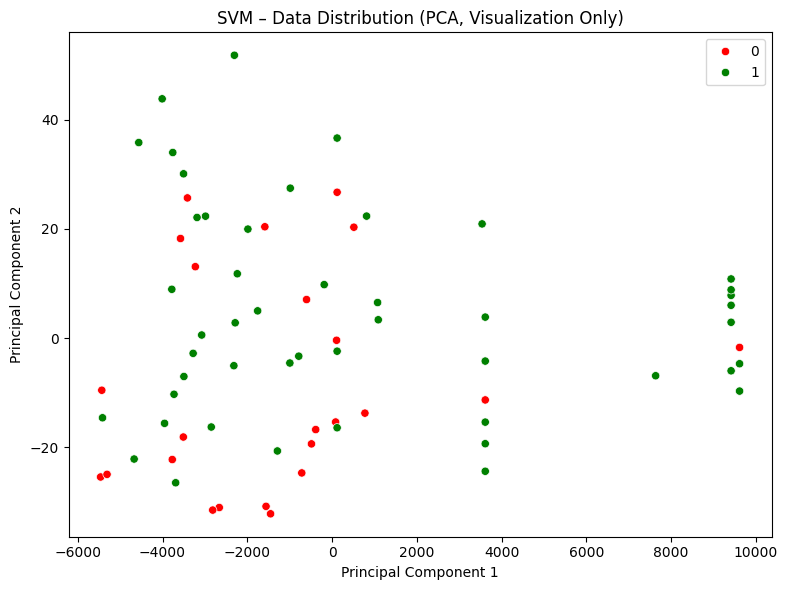

In [46]:
#optional PCA scatter plot
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train)

plt.figure(figsize=(8, 6))
sns.scatterplot(
    x=X_train_pca[:,0],
    y=X_train_pca[:,1],
    hue=Y_train,
    palette={0: 'red', 1: 'green'}
)

plt.title('SVM – Data Distribution (PCA, Visualization Only)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.tight_layout()
plt.show()

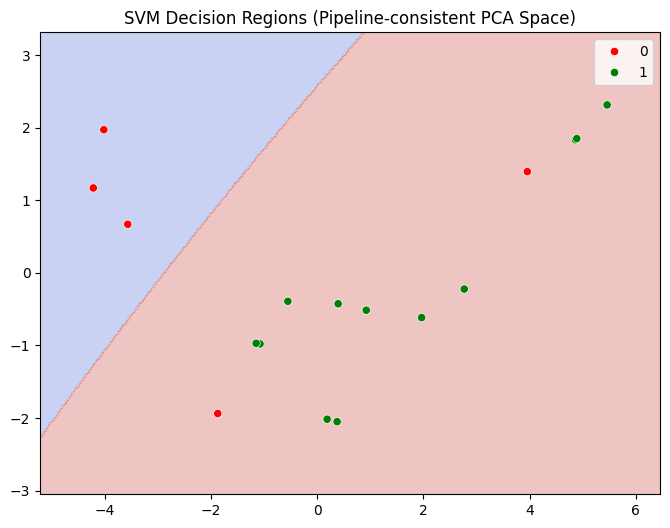

In [48]:
#another extra plot,
pipeline_svm_pca = Pipeline([
    ('scaler', preprocessing.StandardScaler()),
    ('pca', PCA(n_components=2)),
    ('svm', SVC())
])

svm_cv = GridSearchCV(
    pipeline_svm_pca,
    param_grid_svm,
    cv=10
)

svm_cv.fit(X_train, Y_train)

# Transform test data using the SAME pipeline steps
X_test_pca = svm_cv.best_estimator_['pca'].transform(
    svm_cv.best_estimator_['scaler'].transform(X_test)
)

svm = svm_cv.best_estimator_['svm']

xx, yy = np.meshgrid(
    np.linspace(X_test_pca[:,0].min()-1, X_test_pca[:,0].max()+1, 300),
    np.linspace(X_test_pca[:,1].min()-1, X_test_pca[:,1].max()+1, 300)
)

Z = svm.decision_function(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z > 0, alpha=0.3, cmap='coolwarm')
sns.scatterplot(
    x=X_test_pca[:,0],
    y=X_test_pca[:,1],
    hue=Y_test,
    palette={0: 'red', 1: 'green'}
)
plt.title('SVM Decision Regions (Pipeline‑consistent PCA Space)')
plt.show()



In [ ]:
#nice plot right? but I can't say what it tells

## TASK  8


Create a decision tree classifier object then  create a  <code>GridSearchCV</code> object  <code>tree_cv</code> with cv = 10.  Fit the object to find the best parameters from the dictionary <code>parameters</code>.


In [49]:
#Do we  need a Pipeline for Decision Trees? Technically: no (trees don’t need scaling)
parameters = {'criterion': ['gini', 'entropy'],
     'splitter': ['best', 'random'],
     'max_depth': [2*n for n in range(1,10)],
     'max_features': ['log2', 'sqrt'],
     'min_samples_leaf': [1, 2, 4],
     'min_samples_split': [2, 5, 10]}

tree = DecisionTreeClassifier()

In [50]:
tree_cv = GridSearchCV(
    estimator=tree,
    param_grid=parameters,
    cv=10
)
tree_cv.fit(X_train, Y_train)

GridSearchCV(cv=10, estimator=DecisionTreeClassifier(),
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [2, 4, 6, 8, 10, 12, 14, 16, 18],
                         'max_features': ['log2', 'sqrt'],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10],
                         'splitter': ['best', 'random']})

In [51]:
print("tuned hpyerparameters :(best parameters) ",tree_cv.best_params_)
print("accuracy :",tree_cv.best_score_)

tuned hpyerparameters :(best parameters)  {'criterion': 'gini', 'max_depth': 14, 'max_features': 'log2', 'min_samples_leaf': 2, 'min_samples_split': 10, 'splitter': 'best'}
accuracy : 0.875


## TASK  9


Calculate the accuracy of tree_cv on the test data using the method <code>score</code>:


In [52]:

tree_cv.score(X_test, Y_test)


0.7777777777777778

We can plot the confusion matrix


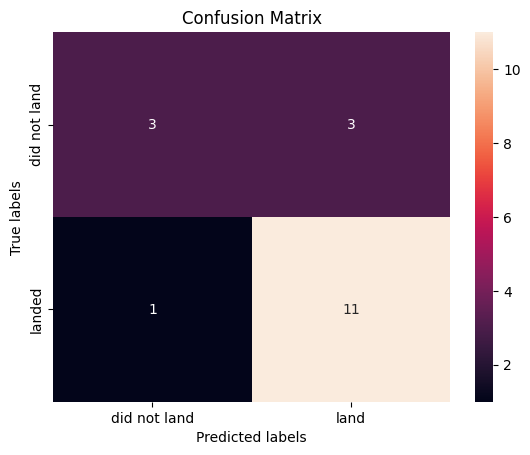

In [53]:
yhat = tree_cv.predict(X_test)
plot_confusion_matrix(Y_test,yhat)

In [54]:
#extra detailed performance evaluation
yhat = tree_cv.predict(X_test)

# Probabilities + ROC AUC
yhat_proba = tree_cv.predict_proba(X_test)[:, 1]
print("ROC AUC score:", roc_auc_score(Y_test, yhat_proba))

# Classification report
print(classification_report(Y_test, yhat))

ROC AUC score: 0.8472222222222222
              precision    recall  f1-score   support

           0       0.75      0.50      0.60         6
           1       0.79      0.92      0.85        12

    accuracy                           0.78        18
   macro avg       0.77      0.71      0.72        18
weighted avg       0.77      0.78      0.76        18



<ipython-input-55-ea649f362247>:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


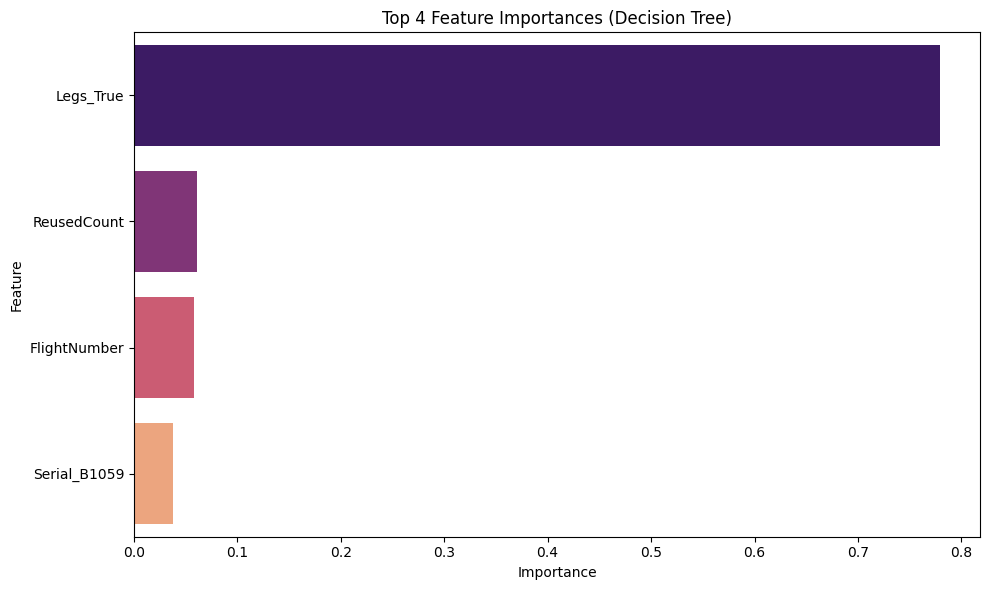

In [55]:
#optional feature importance
feature_importance_tree = pd.DataFrame({
    'Feature': feature_names,
    'Importance': tree_cv.best_estimator_.feature_importances_
})

feature_importance_tree = feature_importance_tree.sort_values(
    by='Importance', ascending=False
)
top_tree_features = feature_importance_tree.head(4)

plt.figure(figsize=(10, 6))
sns.barplot(
    x='Importance',
    y='Feature',
    data=top_tree_features,
    palette='magma'
)

plt.title('Top 4 Feature Importances (Decision Tree)')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()


## TASK  10


Create a k nearest neighbors object then  create a  <code>GridSearchCV</code> object  <code>knn_cv</code> with cv = 10.  Fit the object to find the best parameters from the dictionary <code>parameters</code>.


In [125]:
pipeline_knn = Pipeline([
    ('scaler', preprocessing.StandardScaler()),
    ('knn', KNeighborsClassifier())
])

param_grid_knn = {
    'knn__n_neighbors': list(range(1, 11)),
    'knn__p': [1, 2]  # 1 = Manhattan, 2 = Euclidean
}

knn_cv = GridSearchCV(
    estimator=pipeline_knn,
    param_grid=param_grid_knn,
    cv=10
)

knn_cv.fit(X_train, Y_train)


GridSearchCV(cv=10,
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('knn', KNeighborsClassifier())]),
             param_grid={'knn__n_neighbors': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
                         'knn__p': [1, 2]})

In [109]:
print("tuned hpyerparameters :(best parameters) ",knn_cv.best_params_)
print("accuracy :",knn_cv.best_score_)

tuned hpyerparameters :(best parameters)  {'knn__n_neighbors': 10, 'knn__p': 1}
accuracy : 0.8482142857142858


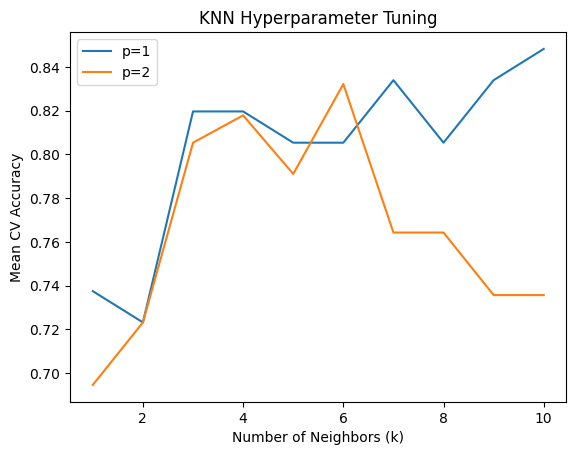

In [110]:
results = pd.DataFrame(knn_cv.cv_results_)

for p in [1, 2]:
    subset = results[results['param_knn__p'] == p]
    plt.plot(subset['param_knn__n_neighbors'],
             subset['mean_test_score'],
             label=f'p={p}')

plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Mean CV Accuracy')
plt.title('KNN Hyperparameter Tuning')
plt.legend()
plt.show()

## TASK  11


Calculate the accuracy of knn_cv on the test data using the method <code>score</code>:


In [111]:
knn_cv.score(X_test, Y_test)

0.8333333333333334

We can plot the confusion matrix


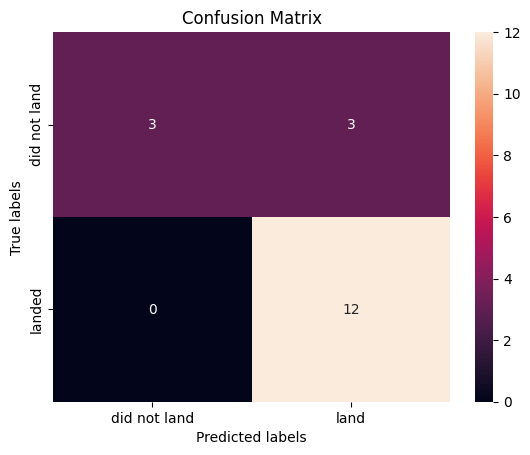

In [112]:
yhat = knn_cv.predict(X_test)
plot_confusion_matrix(Y_test,yhat)

In [113]:
# Predictions (class labels)
yhat_tree = knn_cv.predict(X_test)

# Probabilities for ROC AUC (column 1 = probability of class "1")
yhat_tree_proba = knn_cv.predict_proba(X_test)[:, 1]

# ROC AUC
print("ROC AUC score:", roc_auc_score(Y_test, yhat_tree_proba))

# Classification report
print(classification_report(Y_test, yhat_tree))

ROC AUC score: 0.8472222222222222
              precision    recall  f1-score   support

           0       1.00      0.50      0.67         6
           1       0.80      1.00      0.89        12

    accuracy                           0.83        18
   macro avg       0.90      0.75      0.78        18
weighted avg       0.87      0.83      0.81        18



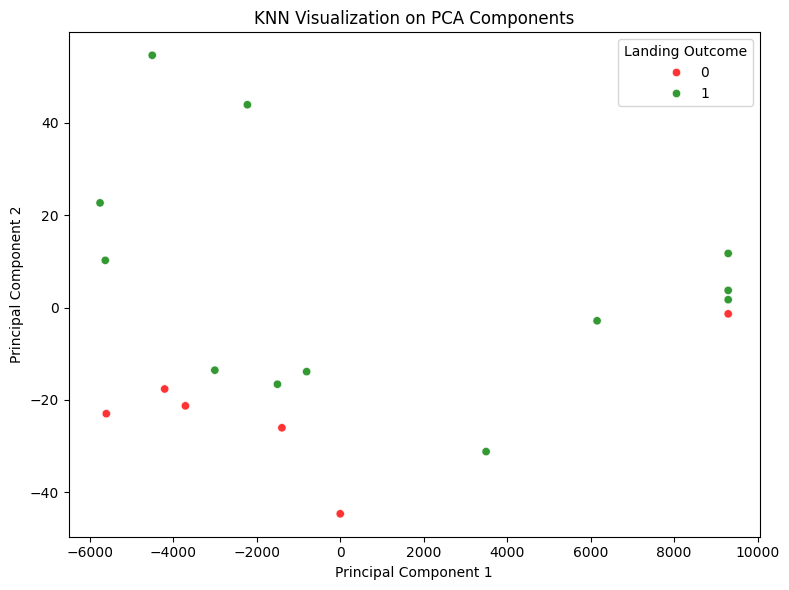

In [114]:
#optional reduce data to 2 dimiensions
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

X_train_pca, X_test_pca, Y_train, Y_test = train_test_split(
    X_pca, Y, test_size=0.2, random_state=2
)

#Train KNN on PCA‑reduced data
knn = knn_cv.best_estimator_   # use the tuned model
knn.fit(X_train_pca, Y_train)
#Scatter plot of the data points
plt.figure(figsize=(8, 6))
sns.scatterplot(
    x=X_test_pca[:, 0],
    y=X_test_pca[:, 1],
    hue=Y_test,
    palette={0: 'red', 1: 'green'},
    alpha=0.8
)

plt.title('KNN Visualization on PCA Components')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Landing Outcome')
plt.tight_layout()
plt.show()


## TASK  12



Find the method performs best:


In [118]:
#logreg_final = logreg_cv     # Logistic Regression pipeline
#svm_final    = svm_cv        # SVM pipeline (NO PCA)
#tree_final   = tree_cv       # Decision Tree pipeline
#knn_final    = knn_cv        # KNN pipeline

In [119]:
print("Logistic Regression accuracy:", logreg_acc)
print("SVM accuracy:", svm_acc)
print("Decision Tree accuracy:", tree_acc)
print("KNN accuracy:", knn_acc)

Logistic Regression accuracy: 0.8333333333333334
SVM accuracy: 0.8333333333333334
Decision Tree accuracy: 0.7777777777777778
KNN accuracy: 0.8333333333333334


<ipython-input-121-d2be764c2a56>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


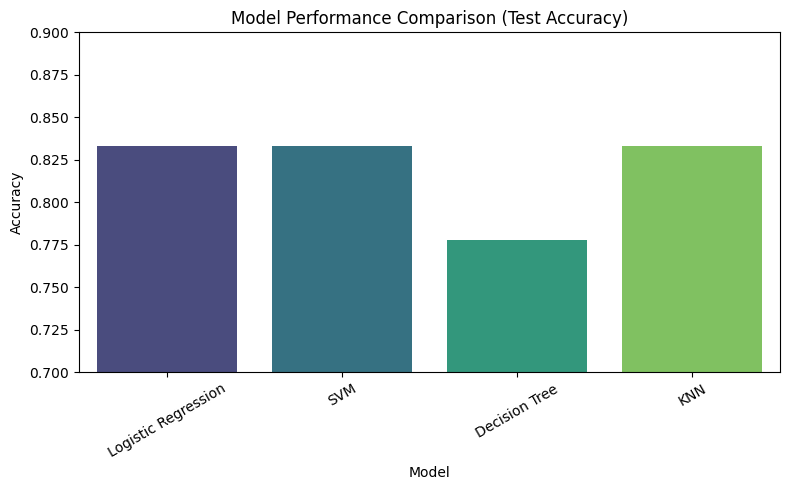

In [121]:
plt.figure(figsize=(8, 5))
sns.barplot(
    x='Model',
    y='Test Accuracy',
    data=results,
    palette='viridis'
)

plt.ylim(0.7, 0.9)
plt.title('Model Performance Comparison (Test Accuracy)')
plt.ylabel('Accuracy')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [122]:
from sklearn.metrics import roc_auc_score, classification_report

results = pd.DataFrame({
    'Model': ['Logistic Regression', 'SVM', 'Decision Tree', 'KNN'],
    'Accuracy': [logreg_acc, svm_acc, tree_acc, knn_acc],
    'ROC AUC': [
        roc_auc_score(Y_test, logreg_cv.predict_proba(X_test)[:, 1]),
        roc_auc_score(Y_test, svm_cv.decision_function(X_test)),
        roc_auc_score(Y_test, tree_cv.predict_proba(X_test)[:, 1]),
        roc_auc_score(Y_test, knn_cv.predict_proba(X_test)[:, 1])
    ]
})

results

/lib/python3.12/site-packages/sklearn/base.py:486: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


<class 'ValueError'>: X has 83 features, but StandardScaler is expecting 2 features as input.

In [89]:
##The decision tree worked best with these paremeter
##tuned hpyerparameters :(best parameters)  {'criterion': 'gini', 'max_depth': 4, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 10, 'splitter': 'random'}
##accuracy : 0.8892857142857145
##We could look at a different models, like boosted random forest models. however I would investigate further on the false classied cases. maybe there was something wrong with those launches which can not be  explained by our given data. Maybe there was a manufacturing issue, a bird hit the rocket, etc.

## Authors


[Pratiksha Verma](https://www.linkedin.com/in/pratiksha-verma-6487561b1/)


<!--## Change Log--!>


<!--| Date (YYYY-MM-DD) | Version | Changed By      | Change Description      |
| ----------------- | ------- | -------------   | ----------------------- |
| 2022-11-09        | 1.0     | Pratiksha Verma | Converted initial version to Jupyterlite|--!>


### <h3 align="center"> IBM Corporation 2022. All rights reserved. <h3/>
